In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns


In [2]:
df=pd.read_csv(r'C:\Users\Rajendhar\OneDrive\Desktop\varun\customer_shopping_behavior.csv')

### 1. Display Top 5 rows

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


### 2. Find the Shape of the Data(Number of Rows and Columns)

In [4]:
df.shape

(3900, 18)

### 3. Dataset structure Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

### 4. Describe the Dataset

In [6]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


### 5. Check Missing values


In [11]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

<Axes: >

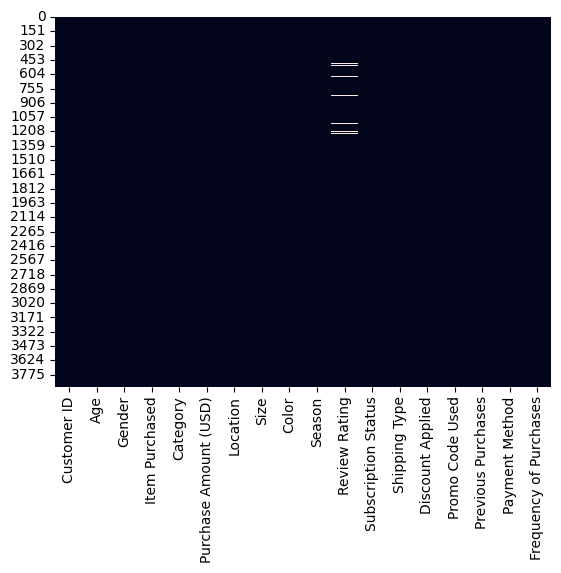

In [17]:
sns.heatmap(df.isnull(), cbar=False)


### 6. Drop all the missing values

In [8]:
df['Review Rating']=df.groupby('Category')['Review Rating'].transform(lambda x:x.fillna(x.median()))

In [7]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

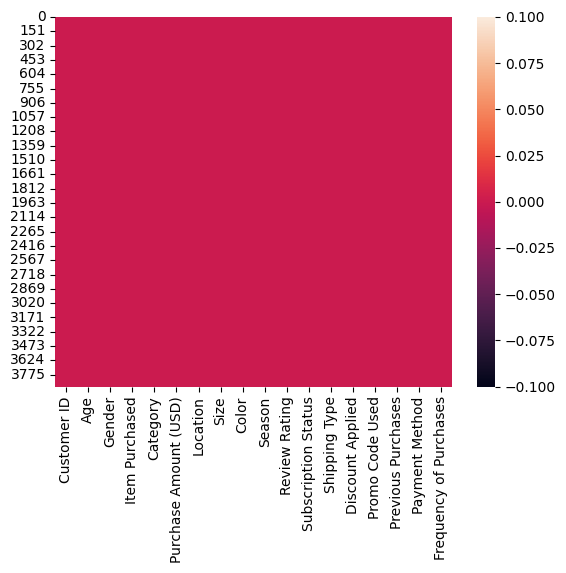

In [9]:
import matplotlib.pyplot as plt
sns.heatmap(df.isnull())
plt.show()

In [10]:
df.columns = df.columns.str.strip()


In [11]:
df.rename(columns=lambda x: x.strip().replace(' ', '_').replace('(USD)', ''), inplace=True)


In [12]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category',
       'Purchase_Amount_', 'Location', 'Size', 'Color', 'Season',
       'Review_Rating', 'Subscription_Status', 'Shipping_Type',
       'Discount_Applied', 'Promo_Code_Used', 'Previous_Purchases',
       'Payment_Method', 'Frequency_of_Purchases'],
      dtype='object')

### 7. Create a column Age_group

In [13]:
bins = [0, 25, 40, 60, 150]
labels = ['Young adult', 'Adult', 'Middle aged', 'Senior']

df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [14]:
df[['Age','Age_group']].head(10)

,Age,Age_group
0,55,Middle aged
1,19,Young adult
2,50,Middle aged
3,21,Young adult
4,45,Middle aged
5,46,Middle aged
6,63,Senior
7,27,Adult
8,26,Adult
9,57,Middle aged


In [67]:
# Convert dictionary keys to lowercase
frequency_map = {k.lower(): v for k, v in frequency_map.items()}

# Map against the lowercase version of the column
df['purchase_frequency_days'] = df['Frequency_of_Purchases'].str.lower().map(frequency_map)

### 8. Create a column Purchase_frequency_days

In [71]:
frequency_map = {
    'Weekly': 7,
    'Bi-weekly': 14,
    'Bi-Weekly': 14,  # Added this line to match your output
    'Fortnightly': 14,
    'Monthly': 30,
    'Every 3 Months': 90,
    'Quarterly': 90,
    'Annually': 365
}
df['purchase_frequency_days'] = df['Frequency_of_Purchases'].map(frequency_map)

In [72]:
df['purchase_frequency_days'] = df['purchase_frequency_days'].astype('Int64')


In [73]:
df[['Frequency_of_Purchases','purchase_frequency_days']].head(20)

,Frequency_of_Purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,90
7,Weekly,7
8,Annually,365
9,Quarterly,90


In [17]:
df[['Discount_Applied','Promo_Code_Used']].head(10)

,Discount_Applied,Promo_Code_Used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [20]:
(df['Discount_Applied']==df['Promo_Code_Used']).all()

np.True_

In [21]:
df=df.drop('Promo_Code_Used',axis=1)

In [22]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category',
       'Purchase_Amount_', 'Location', 'Size', 'Color', 'Season',
       'Review_Rating', 'Subscription_Status', 'Shipping_Type',
       'Discount_Applied', 'Previous_Purchases', 'Payment_Method',
       'Frequency_of_Purchases', 'Age_group', 'purchase_frequency_days'],
      dtype='object')

### 9. Connecting Python script to MySQL

In [74]:
import pandas as pd
from sqlalchemy import create_engine
import urllib.parse

# 1. Connection Details
username = "root"
password = "@RAJ12345"  # Replace with your real password
host = "127.0.0.1"                 # Changed from 'localhost' to '127.0.0.1'
port = "3306"
database = "customer_behavior"

# Encode password to handle special characters (@, #, etc.)
safe_password = urllib.parse.quote_plus(password)

# 2. Updated Connection String
# Using 127.0.0.1 avoids the "getaddrinfo failed" error
engine = create_engine(f"mysql+mysqlconnector://{username}:{safe_password}@{host}:{port}/{database}")

# 3. Test and Write
try:
    # Check if your dataframe 'df' exists
    if 'df' in locals():
        df.to_sql("customer", engine, if_exists="replace", index=False)
        print("Successfully connected and table 'customer' created!")
        
        # Read back test
        check_df = pd.read_sql("SELECT * FROM customer LIMIT 20", engine)
        display(check_df)
    else:
        print("Error: DataFrame 'df' not found. Please define 'df' before running this.")

except Exception as e:
    print(f"Connection Error: {e}")

Successfully connected and table 'customer' created!


,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_,Location,Size,Color,Season,Review_Rating,Subscription_Status,Shipping_Type,Discount_Applied,Previous_Purchases,Payment_Method,Frequency_of_Purchases,Age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle aged,365
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,14,Venmo,Weekly,Middle aged,7
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,49,Cash,Quarterly,Senior,90
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,19,Credit Card,Weekly,Adult,7
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Express,Yes,8,Venmo,Annually,Adult,365
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,4,Cash,Quarterly,Middle aged,90
